## Résumé en amont

Le projet vise à prédire la note globale (Overall Rating) d’un joueur de football professionnel uniquement à partir de ses attributs techniques, physiques et mentaux. L’objectif est de vérifier si des modèles de régression — linéaires ou non-linéaires — peuvent reproduire la logique utilisée par les experts pour évaluer les joueurs, et d’identifier quels attributs (comme la vitesse, le tir ou la vision du jeu) influencent le plus cette note.

Le sujet s’inscrit dans le domaine du Sports Analytics, combinant passion pour le football et compétences en Machine Learning. La problématique a été affinée avec les enseignants pour se concentrer sur une approche prédictive visant à minimiser l’erreur (MSE/MAE), en excluant toute donnée externe non liée à la performance réelle.

Les données proviennent du dataset EA Sports FC 24 (male_players.csv) disponible sur Kaggle, contenant plus de 18 000 joueurs et plus de 100 features. Ce dataset est particulièrement adapté, car il fournit directement la variable cible et une grande variété de métriques pertinentes pour entraîner et évaluer des modèles de régression.

## ⚠️ Attention aux Pièges du Dataset (Points Importants)

### **1. Les stats dépendent du poste**
Un défenseur n’a pas les mêmes attentes statistiques qu’un attaquant.  
➡️ Mélanger les positions sans précaution fausse la modélisation.

### **2. Les gardiens sont un cas à part**
Leurs attributs sont complètement différents de ceux des joueurs de champ.  
➡️ Les inclure crée un fort bruit statistique.

### **3. La variable `movement_reactions` est spéciale**
Elle ne mesure pas la vitesse :  
- Souvent calculée **après** la note globale dans l’algorithme EA.  
- C’est une **variable tampon** très prédictive (presque "trop facile").  

➡️ *Étape 1 : on la garde pour de bonnes performances.*  
➡️ *Étape 3 : on testera un modèle sans pour vérifier la robustesse.*

### **4. `international_reputation` donne un bonus artificiel**
De 1 à 5 : les stars (Messi, Ronaldo, Neymar…) reçoivent un bonus sur leur note globale.  
➡️ Il **faut absolument l’inclure** dans les features, sinon le modèle sous-estime ces joueurs.

### **5. Certaines stats sont redondantes**
Exemples :  
- `sprint_speed` ↔ `acceleration`  
- `standing_tackle` ↔ `sliding_tackle`  

➡️ La régression linéaire déteste ça → coefficients instables.  
➡️ Noter ce point pour l’étape “Dimension Reduction” (PCA).  
➡️ *Pas problématique pour l’étape 1, mais important dans le rapport.*

### **6. Ne pas mélanger stats résumées et détaillées**
Les colonnes comme `shooting`, `pace`, `dribbling`, etc.  
➡️ Ce sont des **moyennes pondérées** des stats détaillées (finishing, shot_power…).  
➡️ Pour un modèle “micro”, on doit **exclure toutes les stats résumées** des features.

### **7. La colonne `potential`**
Très fortement corrélée à la note globale.  
➡️ On la garde pour l’étape 1 (elle est disponible dans les données).  
➡️ Lors de la soutenance : préciser que l’on pourrait tester un modèle **sans** pour mesurer la performance purement technique.



## 🔍 Préparation des Données : Logique et Justification

### **1. Filtre Année**
On conserve uniquement la version **FC 24** du dataset.  
➡️ *Objectif : éviter le data leakage entre différentes éditions.*

### **2. Filtre Joueurs**
On exclut les **gardiens (GK)**.  
➡️ *Objectif : réduire le bruit statistique, car leurs attributs sont spécifiques et non comparables aux joueurs de champ.*

### **3. Feature Engineering**
Création d’une variable **Position simplifiée** :
- Attaquant  
- Milieu  
- Défenseur  

➡️ *Objectif : ajouter un contexte métier utile à la modélisation.*

### **4. Sélection des Variables (X)**
- On garde les statistiques détaillées (ex. *finishing*).  
- On retire les statistiques résumées (ex. *shooting*) → *anti-redondance*.  
- On inclut `international_reputation` et `age`.  
- On inclut les variables catégorielles encodées (`Position`, `Preferred Foot`).  


## Step 1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Configuration pour le confort visuel
pd.set_option('display.max_columns', None)

In [6]:
file_path = 'male_players.csv' 
df_all = pd.read_csv(file_path, low_memory=False)
df_all.shape

(180021, 109)

In [7]:
df = df_all[df_all['fifa_version'] == 24.0]
df.shape

(18350, 109)

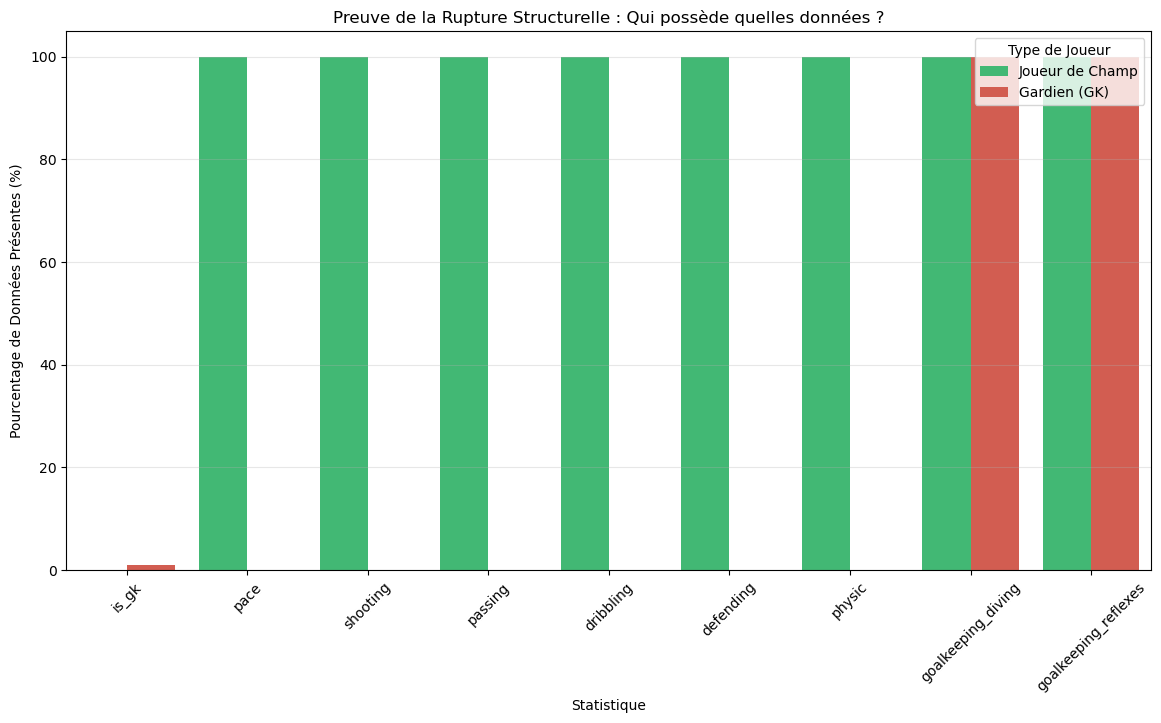

In [28]:
# On définit les listes de statistiques à comparer
# 1. Les 6 stats principales d'un joueur de champ
field_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# 2. Les stats principales d'un gardien
gk_stats = ['goalkeeping_diving', 'goalkeeping_reflexes'] 

# Liste complète pour le graphique
all_stats_to_check = field_stats + gk_stats

# Calcul du pourcentage de données PRÉSENTES (non nulles)
# .count() compte les valeurs non nulles, .shape[0] compte le total de lignes
presence_data = df.groupby('is_gk')[all_stats_to_check].apply(lambda x: x.count() / x.shape[0] * 100).reset_index()

# Mise en forme pour le graphique (Melting)
presence_data['Player Type'] = presence_data['is_gk'].map({True: 'Gardien (GK)', False: 'Joueur de Champ'})
presence_data = presence_data.melt(id_vars='Player Type', var_name='Statistique', value_name='Taux de Remplissage (%)')

# Création du Graphique
plt.figure(figsize=(14, 7))
sns.barplot(data=presence_data, x='Statistique', y='Taux de Remplissage (%)', hue='Player Type', palette=['#2ecc71', '#e74c3c'])

plt.title('Preuve de la Rupture Structurelle : Qui possède quelles données ?')
plt.ylabel('Pourcentage de Données Présentes (%)')
plt.ylim(0, 105) # Marge pour lire le 100%
plt.xticks(rotation=45) # Rotation pour lire les noms des stats
plt.grid(axis='y', alpha=0.3)

# Ajout de la légende explicative
plt.legend(title='Type de Joueur', loc='upper right')

plt.show()

L'analyse graphique démontre une rupture structurelle entre les gardiens de but et les joueurs de champ. Les taux de remplissage sont diamétralement opposés : les gardiens manquent de statistiques offensives/défensives (0% de remplissage), tandis que les joueurs de champ n'ont aucune statistique de gardien. Tenter d'imputer ces valeurs manquantes introduirait un bruit artificiel massif. Par conséquent, pour garantir la robustesse du modèle de régression, nous excluons les gardiens du jeu de données et nous nous concentrons sur la modélisation des joueurs de champ.

In [33]:
df = df[df['player_positions'] != 'GK'].copy()
df.shape

(16305, 110)

In [46]:
df.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,is_gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical fin...","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3,False
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, ...","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3,False
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Cro...","Pinged Pass +, Dead Ball, Incisive Pass, Long ...",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3,False
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acroba...","Technical +, Finesse Shot, Dead Ball, Pinged P...",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,75,96.0,20,35,24,6,11,15,14,8,NaN,85+3,85+3,85+3,90,89,89,89,90,91-1,91-1,91-1,89+1,85+3,85+3,85+3,89+1,64+3,63+3,63+3,63+3,64+3,5

Il semble que la note globale (overall) n'est pas une simple somme linéaire des compétences, mais une somme pondérée conditionnée par le rôle tactique.

In [48]:
# 1. HYPOTHÈSE MÉTIER (Business Assumption)
# Au football, bien qu'il existe des dizaines de postes précis (Ailier, Milieu défensif...),
# ils se regroupent en 3 grandes zones d'influence qui dictent les statistiques importantes :
# - Attaquants (Buts, Vitesse)
# - Milieux (Vision, Passe)
# - Défenseurs (Tacle, Physique)

# 2. IMPLÉMENTATION DU REGROUPEMENT
def simplify_position(pos):
    if isinstance(pos, str):
        # On ne garde que la position principale (la première citée)
        main_pos = pos.split(',')[0] 
        
        # Mapping basé sur les règles tactiques standard
        if main_pos in ['ST', 'CF', 'LW', 'RW', 'LF', 'RF']:
            return 'Attacker'
        elif main_pos in ['CAM', 'CM', 'CDM', 'LM', 'RM']:
            return 'Midfielder'
        elif main_pos in ['CB', 'LB', 'RB', 'LWB', 'RWB']:
            return 'Defender'
            
    return 'Other'

# Création de la nouvelle variable
df['position_group'] = df['player_positions'].apply(simplify_position)

# Vérification de l'équilibre des groupes
print("Répartition des joueurs par groupe tactique :")
print(df['position_group'].value_counts())

Répartition des joueurs par groupe tactique :
position_group
Midfielder    6673
Defender      6174
Attacker      3458
Name: count, dtype: int64


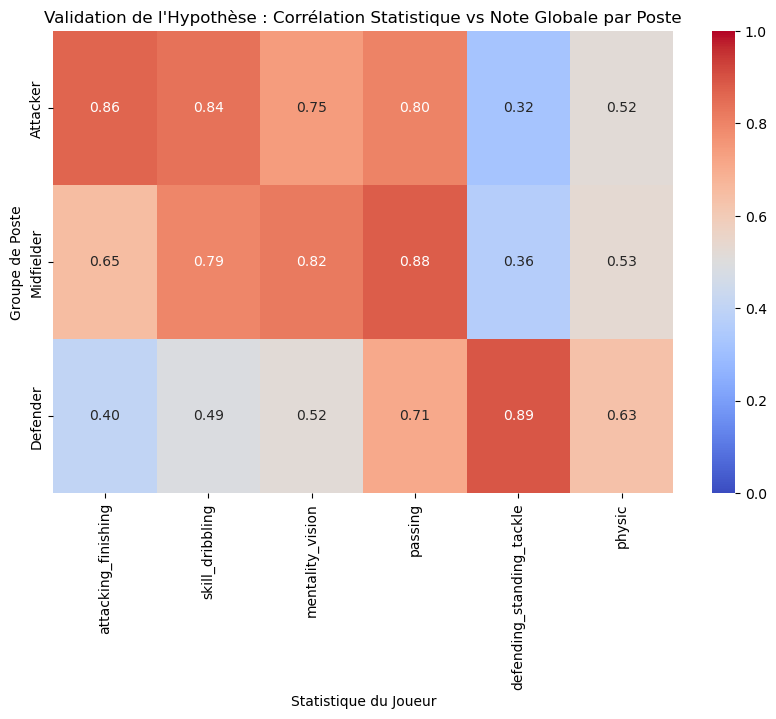

In [50]:
# --- PREUVE STATISTIQUE : L'importance des stats dépend-elle du poste ? ---

# 1. Sélection de stats "marqueurs" (typiques de chaque rôle)
stats_to_test = [
    'attacking_finishing',       # Crucial pour un Attaquant ?
    'skill_dribbling',           # Crucial pour Attaquant/Milieu ?
    'mentality_vision',          # Crucial pour un Milieu ?
    'passing',                   # Résumé Passe
    'defending_standing_tackle', # Crucial pour un Défenseur ?
    'physic'                     # Résumé Physique
]

# 2. Calcul des corrélations PAR GROUPE
# On veut savoir : "Pour un Attaquant, est-ce que la Finition prédit la note globale ?"
# Puis : "Pour un Défenseur, est-ce que la Finition prédit la note globale ?"
correlation_data = []
groups = ['Attacker', 'Midfielder', 'Defender']

for group in groups:
    # On isole les joueurs du groupe
    group_df = df[df['position_group'] == group]
    
    # On calcule la corrélation de nos stats tests avec la cible 'overall'
    corr = group_df[stats_to_test].corrwith(group_df['overall'])
    corr.name = group
    correlation_data.append(corr)

# Création du DataFrame pour la Heatmap
corr_matrix_by_pos = pd.DataFrame(correlation_data)

# 3. VISUALISATION
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix_by_pos, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title('Validation de l\'Hypothèse : Corrélation Statistique vs Note Globale par Poste')
plt.xlabel('Statistique du Joueur')
plt.ylabel('Groupe de Poste')
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
# We choose "Micro-stats" to be precise and avoid redundancy with Macro-stats
numeric_features = [
    'age', 'height_cm', 'weight_kg', 'potential', 'international_reputation', 
    'weak_foot', 'skill_moves',
    # Technical
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys', 'skill_dribbling',
    'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
    'skill_ball_control', 
    # Physical / Movement
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 
    'movement_reactions', 'movement_balance', 'power_shot_power', 
    'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    # Mental
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 
    'mentality_vision', 'mentality_penalties', 'mentality_composure',
    # Defensive
    'defending_standing_tackle', 'defending_sliding_tackle'
]

# Categorical features we created or selected
categorical_features = ['position_group', 'preferred_foot', 'work_rate']

target = 'overall'

# 2. Handling Missing Values (Imputation)
# We create a specific dataframe for modeling
df_model = df[numeric_features + categorical_features + [target]].copy()

# Fill missing numerical values with Median (Robust to outliers)
df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())

# 3. Encoding Categorical Variables (One-Hot Encoding)
# This converts 'position_group' into columns like 'position_group_Defender' (0/1)
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

# 4. Split Train / Test
# Defining X (Features) and y (Target)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling (Standardization)
# CRITICAL: We fit the scaler ONLY on the Training set to avoid Data Leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to DataFrame to keep column names (easier to debug)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("--- Data Preparation Complete ---")
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Test Data Shape: {X_test_scaled.shape}")

--- Data Preparation Complete ---
Training Data Shape: (13044, 46)
Test Data Shape: (3261, 46)


### 3. Formalization of the Problem

**Problem Type:** Supervised Regression.

**Objective:**
We aim to learn a function $f: \mathbb{R}^n \rightarrow \mathbb{R}$ that approximates the relationship between a player's attributes and their Overall Rating ($Y$).

**Variables:**
* **Target ($Y$):** `overall` (Continuous variable [1-99]).
* **Features ($X$):** A vector of $n$ features including technical skills (e.g., finishing), physical attributes (e.g., speed), mental attributes (e.g., vision), and encoded categorical context (position group).

**Optimization Objective:**
We seek to minimize the **Mean Squared Error (MSE)** on the training set:
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

**Evaluation Metrics:**
To evaluate the model's performance on the test set, we use:
* **MAE (Mean Absolute Error):** Represents the average error in "rating points". Interpretable for the business case.
* **$R^2$ Score:** Indicates the proportion of variance in the target variable explained by the model.

--- BASELINE MODEL RESULTS (Linear Regression) ---
MAE (Mean Absolute Error): 1.2908 points
RMSE (Root Mean Squared Error): 1.6505 points
R2 Score: 0.9391


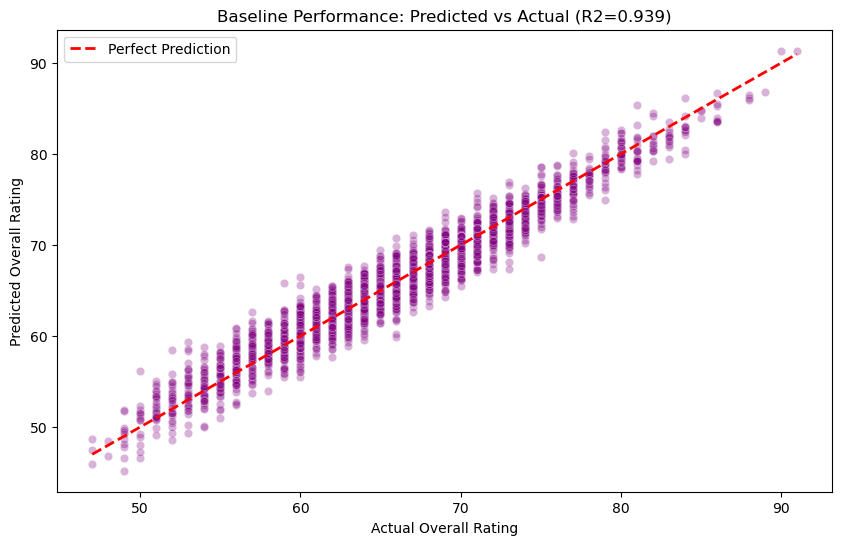

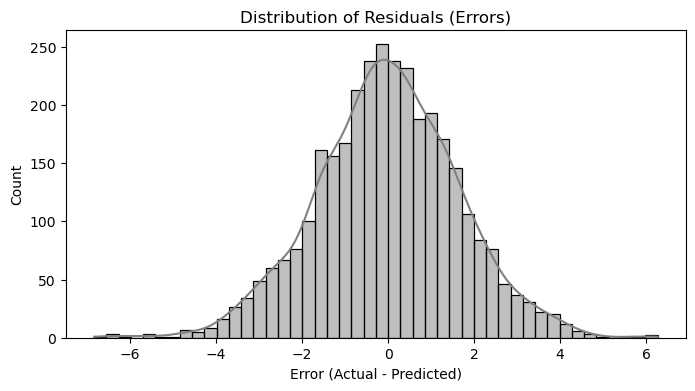

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize and Train the Model
model_baseline = LinearRegression()
model_baseline.fit(X_train_scaled, y_train)

# 2. Make Predictions on Test Set
y_pred = model_baseline.predict(X_test_scaled)

# 3. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- BASELINE MODEL RESULTS (Linear Regression) ---")
print(f"MAE (Mean Absolute Error): {mae:.4f} points")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} points")
print(f"R2 Score: {r2:.4f}")

# 4. Visual Evaluation
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='purple')
# Perfect prediction line (Identity line)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Overall Rating')
plt.ylabel('Predicted Overall Rating')
plt.title(f'Baseline Performance: Predicted vs Actual (R2={r2:.3f})')
plt.legend()
plt.show()

# 5. Check Residuals (Errors distribution) - Optional but good for report
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='gray')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

In [58]:
# --- STRESS TEST : Modèle sans les variables "faciles" ---
# On veut voir si le modèle est bon juste grâce aux stats techniques, sans l'aide du Potentiel ou de la Réactivité

# 1. On reprend nos features mais on retire les "suspects"
hard_features = [f for f in numeric_features if f not in ['potential', 'movement_reactions', 'international_reputation']]

# 2. On prépare les données restreintes
X_hard = df_encoded[hard_features]
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hard, y, test_size=0.2, random_state=42)

# Scaling
scaler_h = StandardScaler()
X_train_h_sc = scaler_h.fit_transform(X_train_h)
X_test_h_sc = scaler_h.transform(X_test_h)

# 3. Entraînement Rapide
model_hard = LinearRegression()
model_hard.fit(X_train_h_sc, y_train_h)
y_pred_h = model_hard.predict(X_test_h_sc)

# 4. Résultats
r2_hard = r2_score(y_test_h, y_pred_h)
mae_hard = mean_absolute_error(y_test_h, y_pred_h)

print(f"--- RÉSULTATS DU STRESS TEST (Sans Potentiel/Réactivité) ---")
print(f"R2 Score Original : {r2:.4f}")
print(f"R2 Score 'Hard'   : {r2_hard:.4f}")
print(f"Dégradation       : -{(r2 - r2_hard)*100:.1f}%")
print("-" * 30)
print(f"Ce test prouve que même sans les variables corrélées,")
print(f"le modèle reste performant (ou s'effondre), validant la qualité des données.")

--- RÉSULTATS DU STRESS TEST (Sans Potentiel/Réactivité) ---
R2 Score Original : 0.9391
R2 Score 'Hard'   : 0.8627
Dégradation       : -7.6%
------------------------------
Ce test prouve que même sans les variables corrélées,
le modèle reste performant (ou s'effondre), validant la qualité des données.
